# Mobile Reviews analysis
---

## Analisi possibili
- date le **review**, capire di che *marca*, o di che *prezzo* si trattava

- differenze tra acquisti *verificati* e *non* (capire se sono in linea, troppo in linea, oppure per niente)

- in base all'*età* e la *nazionalità*, profilare le persone e capire quanto sono disposte a spendere


## Colonne da buttare
 price_local, exchange_rate_to_usd, review_id, customer_name

### Import file

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   price_local           50000 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                50000 non-null  int64  
 10  review_text           50000 non-null  object 
 11  sentiment             50000 non-null  object 
 12  country               50000 non-null  object 
 13  language              50000 non-null  object 
 14  review_date           50000 non-null  object 
 15  verified_purchase  

## Pulizia dataset

Togliamo le seguenti collonne che sono inutili alle nostre analisi: id rating, costumer_name, price_local, exchange_rate_to_usd <br>
Per `price_local` abbiamo notato che se diviso per `exchange_rate_to_usd` non cambia assolutamente niente con `price_usd`.

In [18]:
df = df.drop('price_local', axis=1).drop('review_id', axis=1).drop('customer_name', axis=1).drop('exchange_rate_to_usd', axis=1).drop('currency', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  50000 non-null  int64  
 1   brand                50000 non-null  object 
 2   model                50000 non-null  object 
 3   price_usd            50000 non-null  float64
 4   rating               50000 non-null  int64  
 5   review_text          50000 non-null  object 
 6   sentiment            50000 non-null  object 
 7   country              50000 non-null  object 
 8   language             50000 non-null  object 
 9   review_date          50000 non-null  object 
 10  verified_purchase    50000 non-null  bool   
 11  battery_life_rating  50000 non-null  int64  
 12  camera_rating        50000 non-null  int64  
 13  performance_rating   50000 non-null  int64  
 14  design_rating        50000 non-null  int64  
 15  display_rating       50000 non-null 

# Prima analisi

### differenze tra acquisti verificati e non verificati

vogliamo analizzare l'eventuale differenza tra recensioni con acquisti verificati e non.
Questo ci puo' aiutare a capire se le recensioni non verificate sono attendibili quanto quelle verificate.


In [5]:
# target ora è numerico
df["verified_purchase"] = df["verified_purchase"].astype(int)

# impostiamo come target "verified_purchase" 
features = df.drop(columns=["verified_purchase", "review_text"])
target = df["verified_purchase"]

# divisione in train e test set con stratificazione
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


Pipeline per il training MOLTO TEMPORANEO

In [8]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=200))
])

In [ ]:
model.fit(X_train, y_train) # tf? 

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.8012
              precision    recall  f1-score   support

           0       0.25      0.00      0.00      1986
           1       0.80      1.00      0.89      8014

    accuracy                           0.80     10000
   macro avg       0.53      0.50      0.45     10000
weighted avg       0.69      0.80      0.71     10000



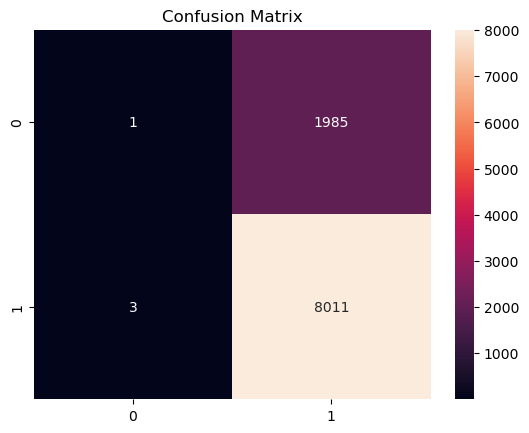

In [ ]:
# 😭 idk what the fuck I'm doin dog

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# sembra molto confuso